# **Exploratory Data Analysis**

In [ ]:
# Importing libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("../src")
import importlib, preprocess

In [3]:
# Loading the data

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

df = pd.read_csv("../data/raw/train.csv")

print(f"Shape: {df.shape}")
df.head()

Shape: (14993, 24)


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,1,1,1,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,1,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


In [4]:
# Filtering dataset to cats only

df_cats = df[df["Type"] == 2].copy()
print(f"All Pets: {df.shape[0]:,}  |  Cats Only: {df_cats.shape[0]:,}")

All Pets: 14,993  |  Cats Only: 6,861


In [5]:
# Checking missing values

missing = df_cats.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nColumns with Missing Values:")
print(missing if len(missing) else "  (none)")


Columns with Missing Values:
Name           612
Description      9
dtype: int64



AdoptionSpeed Distribution (cats):
  0:   240  (3.5%)
  1: 1,655  (24.1%)
  2: 1,873  (27.3%)
  3: 1,310  (19.1%)
  4: 1,783  (26.0%)


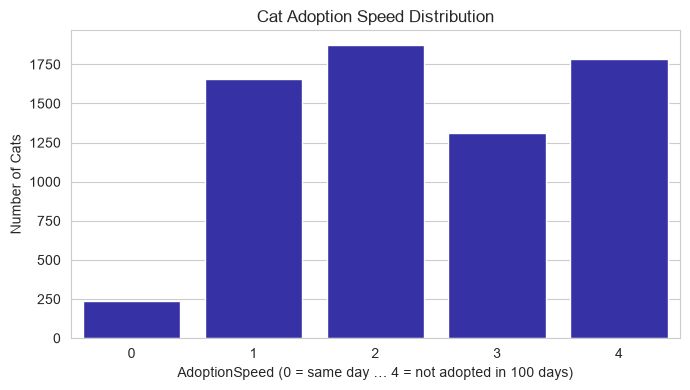

In [6]:
# Inspecting AdoptionSpeed distribution

speed_counts = df_cats["AdoptionSpeed"].value_counts().sort_index()
speed_props = df_cats["AdoptionSpeed"].value_counts(normalize=True).sort_index()

print("\nAdoptionSpeed Distribution (cats):")
for k in speed_counts.index:
    print(f"  {k}: {speed_counts[k]:>5,}  ({speed_props[k]:.1%})")

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=speed_counts.index, y=speed_counts.values, ax=ax, color="#241FB9")
ax.set_xlabel("AdoptionSpeed (0 = same day … 4 = not adopted in 100 days)")
ax.set_ylabel("Number of Cats")
ax.set_title("Cat Adoption Speed Distribution")
plt.tight_layout()
plt.show()

In [7]:
# Creating the binary target variable ({0, 1, 2} = fast <1mo adoption (1), {3, 4} = slow/no adoption (0))

df_cats["adopted_fast"] = (df_cats["AdoptionSpeed"] <= 2).astype(int)

print("Binary Target Balance:")
print(df_cats["adopted_fast"].value_counts(normalize=True).rename({0: "slow/no", 1: "fast"}))

Binary Target Balance:
adopted_fast
fast       0.549191
slow/no    0.450809
Name: proportion, dtype: float64


In [8]:
# Inspecting records where there is more than 1 cat

print(f"\nQuantity > 1 (group listings): {(df_cats['Quantity'] > 1).sum():,} ({(df_cats['Quantity'] > 1).mean():.1%})")
print("Quantity Distribution (top values):")
print(df_cats["Quantity"].value_counts().sort_index().head(8))


Quantity > 1 (group listings): 1,918 (28.0%)
Quantity Distribution (top values):
Quantity
1    4943
2     811
3     469
4     321
5     185
6      68
7      27
8       7
Name: count, dtype: int64


In [9]:
# Checking fast-adoption rate by single/multi-cat listings

print("\nFast-adoption rate by listing type:")
print(df_cats.groupby(df_cats["Quantity"] == 1)["adopted_fast"].mean().rename({False: "group", True: "single"}))


Fast-adoption rate by listing type:
Quantity
group     0.506778
single    0.565648
Name: adopted_fast, dtype: float64


Around 28% of the data involve listings with more than 1 cat. Filtering the dataset to single-cat listings only will be the right call, as there will still be enough data for the XGBoost model to learn from. Additionally, single-cat listings tend to have faster adoptions, justifying this decision further.

In [10]:
# Filtering to single-cat listings only

df_cats_single = df_cats[df_cats["Quantity"] == 1].copy()
print(f"Single-cat listings: {df_cats_single.shape[0]:,} (dropped {df_cats.shape[0] - df_cats_single.shape[0]:,} group listings)")

print("\nBinary Target Balance (single cats):")
print(df_cats_single["adopted_fast"].value_counts(normalize=True).rename({0: "slow/no", 1: "fast"}))

Single-cat listings: 4,943 (dropped 1,918 group listings)

Binary Target Balance (single cats):
adopted_fast
fast       0.565648
slow/no    0.434352
Name: proportion, dtype: float64


After filtering to single-cat listings only, the binary target balance did not change significantly.

In [11]:
# Inspecting PhotoAmt descriptive statistics

print("PhotoAmt Summary (single cats):")
print(df_cats_single["PhotoAmt"].describe())

PhotoAmt Summary (single cats):
count    4943.000000
mean        3.846450
std         3.251823
min         0.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        30.000000
Name: PhotoAmt, dtype: float64



Fast-Adoption Rate by Photo Count:
                  mean  count
photo_bucket                 
0             0.321839     87
1             0.502596    963
2             0.578240    818
3             0.571268    891
4-5           0.614996   1387
6+            0.563363    797


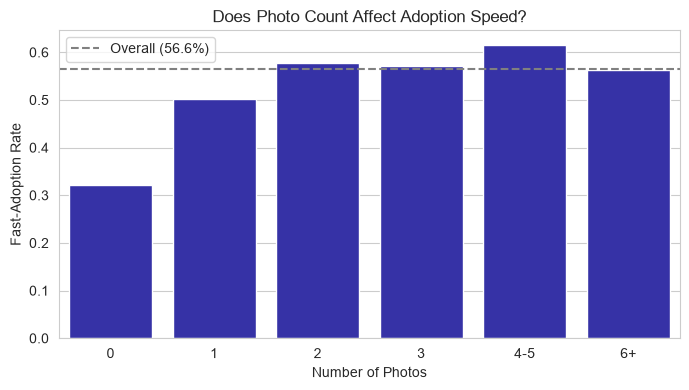

In [12]:
# Inspecting fast-adoption rates across different photo-count buckets

bins = [-0.1, 0, 1, 2, 3, 5, 100]
labels = ["0", "1", "2", "3", "4-5", "6+"]
df_cats_single["photo_bucket"] = pd.cut(df_cats_single["PhotoAmt"], bins=bins, labels=labels)

rate_by_photos = df_cats_single.groupby("photo_bucket", observed=True)["adopted_fast"].agg(["mean", "count"])
print("\nFast-Adoption Rate by Photo Count:")
print(rate_by_photos)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=rate_by_photos.index, y=rate_by_photos["mean"], ax=ax, color="#241FB9")
ax.axhline(df_cats_single["adopted_fast"].mean(), ls="--", color="gray",
           label=f"Overall ({df_cats_single['adopted_fast'].mean():.1%})")
ax.set_xlabel("Number of Photos")
ax.set_ylabel("Fast-Adoption Rate")
ax.set_title("Does Photo Count Affect Adoption Speed?")
ax.legend()
plt.tight_layout()
plt.show()

Having photos tend to improve adoption rate, but having too many photos may hurt it instead. The sweet spot is around 4-5 photos.

In [13]:
# Building description features

desc = df_cats_single["Description"].fillna("")
df_cats_single["has_description"] = (desc.str.strip().str.len() > 0).astype(int)
df_cats_single["desc_char_len"]   = desc.str.len()
df_cats_single["desc_word_count"] = desc.str.split().apply(len)

In [14]:
# Checking if the presence of a description affects adoption rate

print("Fast-Adoption Rate by Description Presence:")
print(df_cats_single.groupby("has_description")["adopted_fast"].agg(["mean", "count"]))

Fast-Adoption Rate by Description Presence:
                     mean  count
has_description                 
0                0.714286      7
1                0.565438   4936


Cats that have no description tend to be adopted faster, but there are only 7 records showing so in contrast to 4936 cats having a description, therefore this data is noise.


Fast-Adoption Rate by Description Word Count (cats with a description):
                      mean  count
wordcount_bucket                 
1-20              0.534082   1247
21-50             0.575017   1433
51-100            0.567293   1278
101-200           0.602347    767
200+              0.540284    211


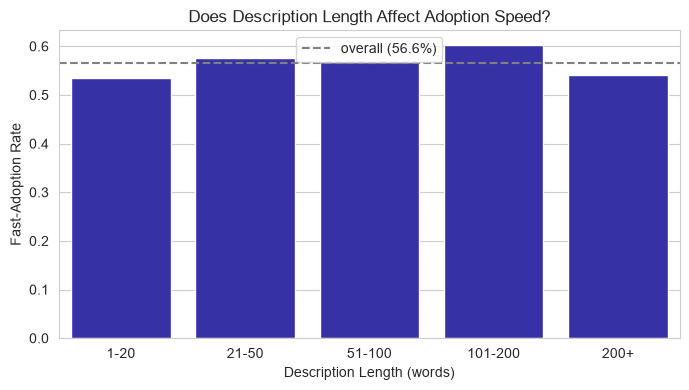

In [15]:
# Checking if longer descriptions help adoption rate among listings with a description

with_desc = df_cats_single[df_cats_single["has_description"] == 1].copy()
bins = [0, 20, 50, 100, 200, 10000]
labels = ["1-20", "21-50", "51-100", "101-200", "200+"]
with_desc["wordcount_bucket"] = pd.cut(with_desc["desc_word_count"], bins=bins, labels=labels)

rate_by_len = with_desc.groupby("wordcount_bucket", observed=True)["adopted_fast"].agg(["mean", "count"])
print("\nFast-Adoption Rate by Description Word Count (cats with a description):")
print(rate_by_len)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=rate_by_len.index, y=rate_by_len["mean"], ax=ax, color="#241FB9")
ax.axhline(df_cats_single["adopted_fast"].mean(), ls="--", color="gray",
           label=f"overall ({df_cats_single['adopted_fast'].mean():.1%})")
ax.set_xlabel("Description Length (words)")
ax.set_ylabel("Fast-Adoption Rate")
ax.set_title("Does Description Length Affect Adoption Speed?")
ax.legend()
plt.tight_layout()
plt.show()

Like what happened with listing photo count, having descriptions too short tend to make the listing underperform, while moderately-long descriptions (101-200) have the highest fast-adoption rate, and having descriptions may also hurt the listing.


Vaccinated vs. Fast-Adoption:
                      mean  count
Vaccinated_label                 
Yes               0.482930   1611
No                0.623584   2824
Not Sure          0.505906    508

Dewormed vs. Fast-Adoption:
                    mean  count
Dewormed_label                 
Yes             0.546624   2799
No              0.611408   1683
Not Sure        0.514100    461

Sterilized vs. Fast-Adoption:
                      mean  count
Sterilized_label                 
Yes               0.400193   1037
No                0.620558   3405
Not Sure          0.534930    501


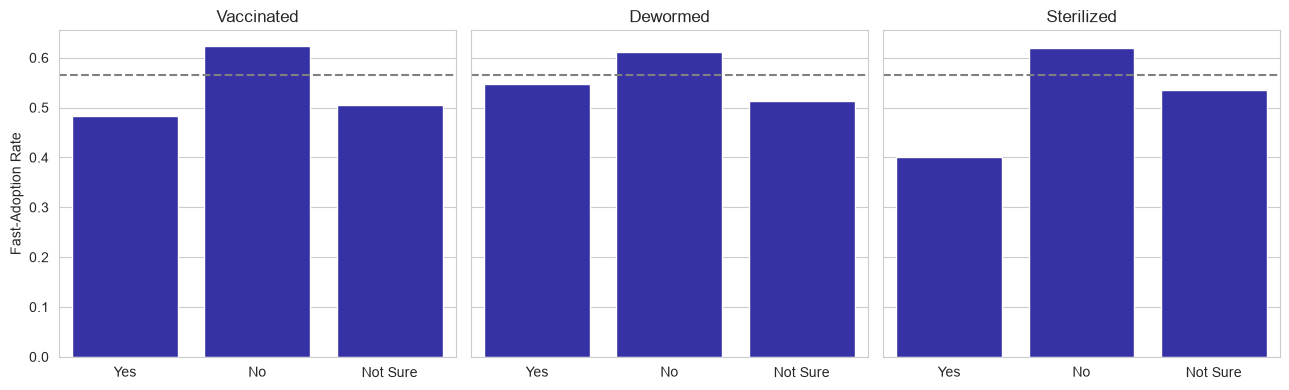

In [ ]:
status_map = {1: "Yes", 2: "No", 3: "Not Sure"}

for col in ["Vaccinated", "Dewormed", "Sterilized"]:
    tmp = df_cats_single.copy()
    tmp[col + "_label"] = tmp[col].map(status_map)
    summary = (tmp.groupby(col + "_label")["adopted_fast"].agg(["mean", "count"]).reindex(["Yes", "No", "Not Sure"]))
    print(f"\n{col} vs. Fast-Adoption:")
    print(summary)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
baseline = df_cats_single["adopted_fast"].mean()
for ax, col in zip(axes, ["Vaccinated", "Dewormed", "Sterilized"]):
    tmp = df_cats_single.copy()
    tmp[col + "_label"] = tmp[col].map(status_map)
    rates = (tmp.groupby(col + "_label")["adopted_fast"].mean().reindex(["Yes", "No", "Not Sure"]))
    sns.barplot(x=rates.index, y=rates.values, ax=ax, color="#241FB9")
    ax.axhline(baseline, ls="--", color="gray")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Fast-Adoption Rate" if col == "Vaccinated" else "")
plt.tight_layout()
plt.show()

Unexpectedly, cats who aren't vaccinated/dewormed/sterilised tend to be adopted faster. To investigate this further, we have to explore whether other variables such as age confound with this.

In [44]:
# Investigating whether the Sterilized feature is confounded by age

status_map = {1: "Yes", 2: "No", 3: "Not Sure"}

df_cats_single["Sterilized_label"] = df_cats_single["Sterilized"].map(status_map)
print("Median Age (months) by Sterilisation Status:")
print(df_cats_single.groupby("Sterilized_label")["Age"].median())

df_cats_single["age_group"] = pd.cut(df_cats_single["Age"],
                                     bins=[-1, 6, 12, 1000],
                                     labels=["kitten (0-6mo)", "young (7-12mo)", "adult (12mo+)"])

print("\nFast-Adoption Rate by Sterilisation Status within each Age Group:")
pivot = df_cats_single.pivot_table(index="age_group", columns="Sterilized_label",
                                   values="adopted_fast", aggfunc="mean", observed=True)
print(pivot.round(3))

print("\nCounts (to watch small cells):")
print(df_cats_single.pivot_table(index="age_group", columns="Sterilized_label",
                                 values="adopted_fast", aggfunc="count", observed=True))

Median Age (months) by Sterilisation Status:
Sterilized_label
No           3.0
Not Sure     4.0
Yes         12.0
Name: Age, dtype: float64

Fast-Adoption Rate by Sterilisation Status within each Age Group:
Sterilized_label     No  Not Sure    Yes
age_group                               
kitten (0-6mo)    0.658     0.634  0.457
young (7-12mo)    0.415     0.363  0.402
adult (12mo+)     0.461     0.378  0.364

Counts (to watch small cells):
Sterilized_label    No  Not Sure  Yes
age_group                            
kitten (0-6mo)    2843       314  258
young (7-12mo)     369       113  361
adult (12mo+)      193        74  418


As expected, the Sterilized feature is confounded by age, as unsterilised cats are mostly young kittens and are coincidentally adopted faster. This may be the same case for the Dewormed and Vaccinated features.

In [ ]:
# Inspecting Fee descriptive statistics

print("Fee summary (single cats):")
print(df_cats_single["Fee"].describe())

Fee summary (single cats):
count    4943.000000
mean       20.285252
std        65.720592
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       800.000000
Name: Fee, dtype: float64

Free (Fee == 0): 4,017 (81.3%)


In [ ]:
# Investigating free vs. paid adoption listings

print(f"\nFree (Fee == 0): {(df_cats_single['Fee'] == 0).sum():,} ({(df_cats_single['Fee'] == 0).mean():.1%})")

df_cats_single["is_free"] = (df_cats_single["Fee"] == 0).astype(int)
print("\nFast-Adoption Rate, Free vs. Paid:")
print(df_cats_single.groupby("is_free")["adopted_fast"].agg(["mean", "count"]).rename(index={0: "paid", 1: "free"}))

paid = df_cats_single[df_cats_single["Fee"] > 0].copy()
bins = [0, 50, 100, 200, 10000]
labels = ["1-50", "51-100", "101-200", "200+"]
paid["fee_bucket"] = pd.cut(paid["Fee"], bins=bins, labels=labels)
print("\nFast-Adoption Rate by Fee Amount (paid listings only):")
print(paid.groupby("fee_bucket", observed=True)["adopted_fast"].agg(["mean", "count"]))


Free (Fee == 0): 4,017 (81.3%)

Fast-Adoption Rate, Free vs. Paid:
             mean  count
is_free                 
paid     0.534557    926
free     0.572816   4017

Fast-Adoption Rate by Fee Amount (paid listings only):
                mean  count
fee_bucket                 
1-50        0.574661    442
51-100      0.487500    240
101-200     0.482759    145
200+        0.545455     99


Like the health features, it is recommended to check whether adoption fee is confounded by age.

In [32]:
# Investigating whether adoption fee is confounded by age

print("\nMedian age by free/paid:")
print(df_cats_single.groupby("is_free")["Age"].median().rename(index={0: "paid", 1: "free"}))


Median age by free/paid:
is_free
paid    4.0
free    4.0
Name: Age, dtype: float64


Adoption fee is not confounded by age.

In [35]:
# Investigating links between other contextual features and the target variable

maturity_map = {1: "Small", 2: "Medium", 3: "Large", 4: "XL", 0: "Not specified"}
fur_map      = {1: "Short", 2: "Medium", 3: "Long", 0: "Not specified"}
health_map   = {1: "Healthy", 2: "Minor Injury", 3: "Serious Injury", 0: "Not Specified"}

baseline = df_cats_single["adopted_fast"].mean()

for col, mp in [("MaturitySize", maturity_map), ("FurLength", fur_map),("Health", health_map)]:
    tmp = df_cats_single.copy()
    tmp[col + "_label"] = tmp[col].map(mp)
    summary = (tmp.groupby(col + "_label")["adopted_fast"].agg(["mean", "count"]).sort_values("mean", ascending=False))
    print(f"\n{col} vs. Fast-Adoption (baseline {baseline:.1%}):")
    print(summary)


MaturitySize vs. Fast-Adoption (baseline 56.6%):
                        mean  count
MaturitySize_label                 
Small               0.608016   1472
XL                  0.571429      7
Large               0.558603    401
Medium              0.546197   3063

FurLength vs. Fast-Adoption (baseline 56.6%):
                     mean  count
FurLength_label                 
Long             0.665738    359
Medium           0.580073   1636
Short            0.545455   2948

Health vs. Fast-Adoption (baseline 56.6%):
                    mean  count
Health_label                   
Healthy         0.569987   4758
Minor Injury    0.476744    172
Serious Injury  0.153846     13


Maturity size, which is the size relative to the maturity of the cat, has a modest link with how fast it gets adopted. Next, fur length contains some signal of the cat's adoption speed. Lastly, the link between the cat's health and how fast it gets adopted is as expected, as healthier cats get adopted faster. However, one thing to note is that only 13 cats have serious injuries, which is a small sample size.


Age vs. Fast-Adoption (baseline 56.6%):
             mean  count
age_bin                 
0-3mo    0.692113   2371
4-6mo    0.523946   1044
7-12mo   0.402135    843
13-24mo  0.381910    398
24mo+    0.407666    287


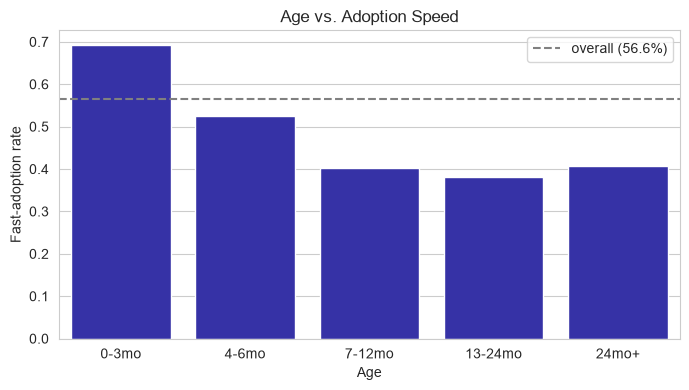

In [38]:
# Investigating links between age and the target variable

df_cats_single["age_bin"] = pd.cut(df_cats_single["Age"],
                                   bins=[-1, 3, 6, 12, 24, 1000],
                                   labels=["0-3mo", "4-6mo", "7-12mo", "13-24mo", "24mo+"])
print(f"\nAge vs. Fast-Adoption (baseline {baseline:.1%}):")
print(df_cats_single.groupby("age_bin", observed=True)["adopted_fast"].agg(["mean", "count"]))


fig, ax = plt.subplots(figsize=(7, 4))
rates = df_cats_single.groupby("age_bin", observed=True)["adopted_fast"].mean()
sns.barplot(x=rates.index, y=rates.values, ax=ax, color="#241FB9")
ax.axhline(baseline, ls="--", color="gray", label=f"overall ({baseline:.1%})")
ax.set_xlabel("Age"); ax.set_ylabel("Fast-adoption rate")
ax.set_title("Age vs. Adoption Speed")
ax.legend()
plt.tight_layout()
plt.show()

Age may be a strong signal for how fast a cat gets adopted, as younger cats tend to get adopted faster, with very young kittens aged 0-3 months being adopted significantly faster. The minor increase in fast-adoption rate for cats aged 24 months or older is on a small sample as well.

In [40]:
# Defining the final feature list

# === Features to Keep ===
# Actionable levers (drive recommendations):
#   PhotoAmt    -   strongest lever; plateau ~4-5 photos
#   Fee         -   weak lever; free slightly faster (age-confound checked, clean)
# Health-status (recommend CONFIRMING, never changing - confound-aware):
#   Vaccinated, Dewormed, Sterilized  (1 = yes, 2 = no, 3 = not sure)
# Contextual (explain score, no recs):
#   Age                     -   dominant driver
#   FurLength               -   real signal (long > short)
#   MaturitySize, Health
#   Breed1, Color1          -   categorical context
KEEP = [
    "Age", "Breed1", "Color1", "MaturitySize", "FurLength",
    "Vaccinated", "Dewormed", "Sterilized", "Health",
    "Fee", "PhotoAmt",
]

# === Engineered Features ===
#   desc_word_count -   description length, sweet spot 100-200 words
#   is_free         -   Fee == 0 (81% of listings). cheap binary
#   (NOTE: has_description dropped, only 7 cats lack a description)
DERIVED = ["desc_word_count", "is_free"]

# === Dropped Features (with reasons) ===
DROP_REASONS = {
    "Type":             "constant after cat filter (all == 2)",
    "Quantity":         "constant after single-cat filter (all == 1)",
    "PetID":            "identifier - leakage/overfit risk",
    "RescuerID":        "high-cardinality, not a listing-quality lever",
    "Name":             "612 missing, low signal",
    "State":            "geographic (Malaysian states), not a listing lever",
    "Breed2":           "secondary breed, mostly 0/absent",
    "Color2":           "secondary colour, sparse",
    "Color3":           "another secondary colour, sparse",
    "VideoAmt":         "mostly 0, weak",
    "Description":      "raw text not fed to model (used by LLM module + desc_word_count)",
    "AdoptionSpeed":    "raw target, replaced by binary adopted_fast",
}

# === Target Variable ===
TARGET = "adopted_fast" # 1 = adopted within a month (original speed 0-2), else 0

# === Feature Order ===
FEATURE_ORDER = KEEP + DERIVED
print(f"FEATURE_ORDER ({len(FEATURE_ORDER)} features):")
for i, f in enumerate(FEATURE_ORDER, 1):
    print(f"  {i:2d}. {f}")
print(f"\nTarget: {TARGET}")
print(f"Dropped: {len(DROP_REASONS)} columns (see reasons above)")

FEATURE_ORDER (13 features):
   1. Age
   2. Breed1
   3. Color1
   4. MaturitySize
   5. FurLength
   6. Vaccinated
   7. Dewormed
   8. Sterilized
   9. Health
  10. Fee
  11. PhotoAmt
  12. desc_word_count
  13. is_free

Target: adopted_fast
Dropped: 12 columns (see reasons above)


In [42]:
# Examining breed and colour labels for the preprocess script

df_breed_labels = pd.read_csv("../data/raw/BreedLabels.csv")
df_color_labels = pd.read_csv("../data/raw/ColorLabels.csv")
print(df_breed_labels.head())
print(df_breed_labels.columns.tolist())
print(df_color_labels.head())
print(df_color_labels.columns.tolist())

   BreedID  Type         BreedName
0        1     1     Affenpinscher
1        2     1      Afghan Hound
2        3     1  Airedale Terrier
3        4     1            Akbash
4        5     1             Akita
['BreedID', 'Type', 'BreedName']
   ColorID ColorName
0        1     Black
1        2     Brown
2        3    Golden
3        4    Yellow
4        5     Cream
['ColorID', 'ColorName']


In [ ]:
# Testing the preprocess script

importlib.reload(preprocess)

# === Path A: a DataFrame (training-style) ===
train_features = preprocess.preprocess(df_cats_single)
print("DataFrame path:")
print(f"  shape: {train_features.shape}")
print(f"  columns: {train_features.columns.tolist()}")
print(f"  Breed1 dtype: {train_features['Breed1'].dtype}")
print(f"  desc_word_count present: {'desc_word_count' in train_features.columns}")

# === Path B: a single cat as a dict (form-style) ===
one_cat = {
    "Age": 12, "Breed1": 243, "Color1": 1, "MaturitySize": 2, "FurLength": 1,
    "Vaccinated": 1, "Dewormed": 1, "Sterilized": 2, "Health": 1,
    "Fee": 0, "PhotoAmt": 3, "Description": "Friendly tabby, loves people and naps.",
}
one_features = preprocess.preprocess(one_cat)
print("\nDict path:")
print(f"  shape: {one_features.shape}")
print(f"  same columns as training: {one_features.columns.tolist() == train_features.columns.tolist()}")
print(one_features.T)

DataFrame path:
  shape: (4943, 13)
  columns: ['Breed1', 'Color1', 'Age', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Fee', 'PhotoAmt', 'desc_word_count', 'is_free']
  Breed1 dtype: category
  desc_word_count present: True

Dict path:
  shape: (1, 13)
  same columns as training: True
                   0
Breed1           243
Color1             1
Age               12
MaturitySize       2
FurLength          1
Vaccinated         1
Dewormed           1
Sterilized         2
Health             1
Fee                0
PhotoAmt           3
desc_word_count    6
is_free            1
